# 03 — Prix des vols, couverture, et le biais qu'elle cache

Ce notebook publie la mesure la plus inconfortable du projet : **l'axe prix de Nalu
est biaisé, et le biais est proportionnel à la popularité touristique de la
destination.**

Travelpayouts ne fait pas d'interrogation GDS. Il sert des minima issus du **cache de
recherches de ses utilisateurs**. Une destination que personne ne cherche n'a donc pas
de prix — non pas parce qu'aucun vol n'existe, mais parce que personne n'a cherché.

Ce biais était **prévu avant la mesure**, et le plan de repli a été écrit avant d'en
connaître le résultat. Ce notebook mesure, puis vérifie que le repli annoncé a bien
été appliqué.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml

from nalu.config import CONFIG
from nalu.ingest.flights import POPULARITE_PATH, SNAPSHOT_DIR
from nalu.palette import CLAIR, style_matplotlib
from nalu.scoring.combine import construire_tableau, fraicheur_du_snapshot
from nalu.spots import load_raw_spots

plt.rcParams.update(style_matplotlib(CLAIR))
pl.Config.set_tbl_rows(25)

MOIS = ["jan", "fev", "mar", "avr", "mai", "jun",
        "jui", "aou", "sep", "oct", "nov", "dec"]

jour, anciennete = fraicheur_du_snapshot()
print(f"Snapshot de prix collecte le {jour} — il y a {anciennete} jour(s).")
print(f"Origine : {CONFIG.origin_iata}, devise : {CONFIG.currency}")

Snapshot de prix collecte le 2026-08-02 — il y a 1 jour(s).
Origine : PAR, devise : EUR


## 1. La couverture, destination par destination

« Couvert » veut dire ici : **au moins un mois sur douze porte un prix**. C'est une
barre volontairement basse, et la suite montre à quel point le résultat y est
sensible.

In [2]:
snapshot = pl.read_parquet(next(SNAPSHOT_DIR.glob("flights_*.parquet")))
spots = load_raw_spots()
popularite = yaml.safe_load(POPULARITE_PATH.read_text(encoding="utf-8"))

couverture = (
    snapshot.group_by("airport_iata")
    .agg(pl.col("price_eur").is_not_null().sum().alias("mois_avec_prix"))
    .join(
        pl.DataFrame({
            "airport_iata": [s.airport_iata for s in spots],
            "spot": [s.name for s in spots],
        }),
        on="airport_iata",
    )
    .with_columns(
        pl.col("airport_iata")
        .map_elements(lambda i: popularite[i]["tier"], return_dtype=pl.Int64)
        .alias("popularite")
    )
    .sort("mois_avec_prix", descending=True)
)
couverture

airport_iata,mois_avec_prix,spot,popularite
str,u32,str,i64
"""DPS""",11,"""Uluwatu""",3
"""MLE""",10,"""Sultans""",3
"""PPT""",9,"""Teahupo'o""",2
"""LIS""",7,"""Supertubos""",3
"""MRU""",7,"""Tamarin Bay""",3
"""SID""",4,"""Ponta Preta""",2
"""CMB""",4,"""Arugam Bay""",2
"""MEL""",4,"""Bells Beach""",2
"""BIO""",3,"""Mundaka""",3


In [3]:
couverts = (couverture["mois_avec_prix"] > 0).sum()
total = couverture.height
print(f"Destinations couvertes : {couverts}/{total}")
print()
print("Regle de repli, ecrite AVANT la mesure :")
print(f"  >= {CONFIG.coverage_two_axis_min} couverts -> produit a deux axes, tel que specifie")
print(f"  {CONFIG.coverage_restricted_min} a {CONFIG.coverage_two_axis_min - 1}"
      " -> referentiel restreint aux spots couverts")
print(f"  <  {CONFIG.coverage_restricted_min} couverts -> produit MONO-AXE, l'axe prix disparait")
print()
if couverts >= CONFIG.coverage_two_axis_min:
    print("-> deux axes")
elif couverts >= CONFIG.coverage_restricted_min:
    print("-> REFERENTIEL RESTREINT : c'est le cas qui s'applique.")
else:
    print("-> mono-axe")

Destinations couvertes : 15/20

Regle de repli, ecrite AVANT la mesure :
  >= 16 couverts -> produit a deux axes, tel que specifie
  10 a 15 -> referentiel restreint aux spots couverts
  <  10 couverts -> produit MONO-AXE, l'axe prix disparait

-> REFERENTIEL RESTREINT : c'est le cas qui s'applique.


## 2. La corrélation couverture ↔ popularité

C'est le chiffre qui décide si le biais est une hypothèse ou un fait.

La popularité est un rang à trois niveaux, posé **à la main et avant la sonde**, dans
`data/airport_popularity.yaml`, chaque destination avec sa raison. On utilise une
corrélation **de rangs** (Spearman) et non de Pearson : la popularité est ordinale,
pas métrique — l'écart entre les niveaux 1 et 2 n'a pas de raison d'égaler celui
entre 2 et 3.

In [4]:
def rangs(valeurs: np.ndarray) -> np.ndarray:
    """Rangs moyens, ex aequo compris — sans dependance supplementaire."""
    ordre = valeurs.argsort()
    rang = np.empty(len(valeurs), dtype=float)
    rang[ordre] = np.arange(len(valeurs), dtype=float)
    for v in np.unique(valeurs):
        masque = valeurs == v
        rang[masque] = rang[masque].mean()
    return rang

x = rangs(couverture["mois_avec_prix"].to_numpy().astype(float))
y = rangs(couverture["popularite"].to_numpy().astype(float))
spearman = float(np.corrcoef(x, y)[0, 1])

print(f"Correlation de rangs couverture <-> popularite : {spearman:+.2f}")
print()
non_couverts = couverture.filter(pl.col("mois_avec_prix") == 0)
print(f"Destinations sans aucun prix : {non_couverts.height}")
print(non_couverts.select("spot", "airport_iata", "popularite"))
print()
mini = couverture.filter(pl.col("popularite") == couverture["popularite"].min())
print(f"Destinations de popularite minimale : {mini.height}")
print("Les deux ensembles coincident-ils ?",
      set(non_couverts["airport_iata"]) == set(mini["airport_iata"]))

Correlation de rangs couverture <-> popularite : +0.78

Destinations sans aucun prix : 5
shape: (5, 3)
┌─────────────────────────────────┬──────────────┬────────────┐
│ spot                            ┆ airport_iata ┆ popularite │
│ ---                             ┆ ---          ┆ ---        │
│ str                             ┆ str          ┆ i64        │
╞═════════════════════════════════╪══════════════╪════════════╡
│ Thurso East                     ┆ INV          ┆ 1          │
│ Klitmøller                      ┆ AAL          ┆ 1          │
│ Supertubes (Jeffreys Bay)       ┆ PLZ          ┆ 1          │
│ Playa Zicatela (Puerto Escondi… ┆ PXM          ┆ 1          │
│ Chicama                         ┆ TRU          ┆ 1          │
└─────────────────────────────────┴──────────────┴────────────┘

Destinations de popularite minimale : 6
Les deux ensembles coincident-ils ? False


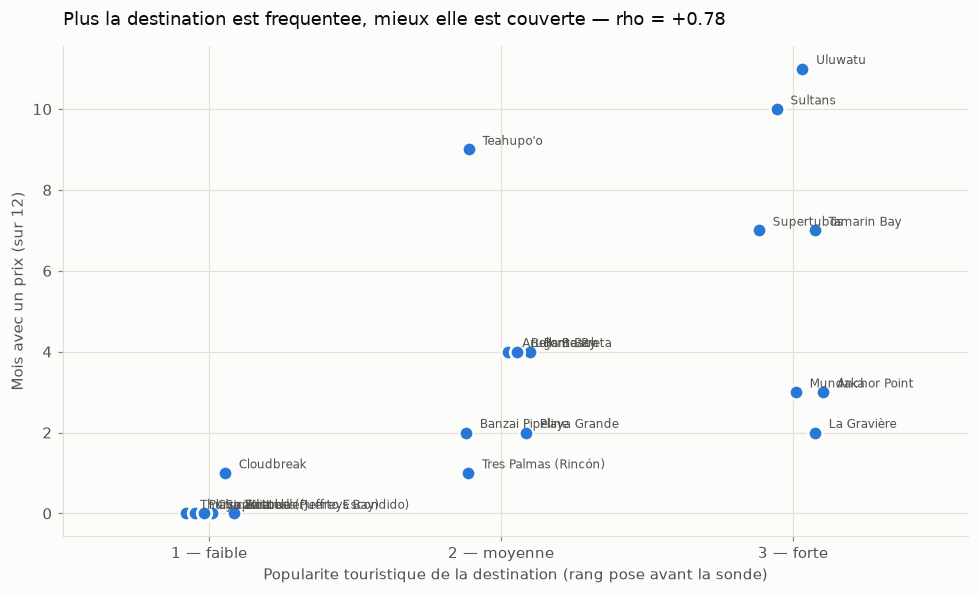

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
# Un point par destination. La popularite est ordinale : on ecarte legerement les
# points d'un meme niveau pour qu'ils cessent de se recouvrir, sans changer la valeur.
generateur = np.random.default_rng(0)
decalage = generateur.uniform(-0.12, 0.12, couverture.height)

ax.scatter(
    couverture["popularite"].to_numpy() + decalage,
    couverture["mois_avec_prix"].to_numpy(),
    s=90, color=CLAIR["serie"], edgecolor=CLAIR["surface"], linewidth=1.8, zorder=3,
)
for ligne, dx in zip(couverture.iter_rows(named=True), decalage, strict=True):
    ax.annotate(
        ligne["spot"], (ligne["popularite"] + dx, ligne["mois_avec_prix"]),
        textcoords="offset points", xytext=(9, 3), fontsize=8, color=CLAIR["encre_2"],
    )
ax.set_xticks([1, 2, 3], ["1 — faible", "2 — moyenne", "3 — forte"])
ax.set_xlabel("Popularite touristique de la destination (rang pose avant la sonde)")
ax.set_ylabel("Mois avec un prix (sur 12)")
ax.set_title(
    f"Plus la destination est frequentee, mieux elle est couverte — rho = {spearman:+.2f}",
    loc="left", pad=14, fontsize=12,
)
ax.set_xlim(0.5, 3.6)
plt.tight_layout()
plt.show()

**Le biais n'est pas une hypothèse, c'est un fait mesuré.** Les destinations sans
aucun prix sont exactement celles de popularité minimale.

Le passage en rang centile aurait rendu ce biais **invisible, pas absent** : sans
cette mesure, le classement final aurait silencieusement corrélé avec la
fréquentation touristique, et personne n'aurait pu le voir dans le produit fini.

### La décision produit qui en découle

Le repli prévu s'applique : **référentiel restreint sur l'axe prix**. Les cinq spots
non couverts **restent affichés** et sont marqués. La restriction porte sur l'axe
prix, jamais sur le référentiel — les faire disparaître laisserait le biais décider du
contenu du produit.

## 3. Ce que « couvert » ne dit pas

Un seul mois servi sur douze suffit à être compté « couvert ». Voici ce que devient la
décision si on relève la barre.

In [6]:
lignes = []
for seuil in (1, 2, 3, 6):
    retenus = (couverture["mois_avec_prix"] >= seuil).sum()
    if retenus >= CONFIG.coverage_two_axis_min:
        decision = "deux axes"
    elif retenus >= CONFIG.coverage_restricted_min:
        decision = "referentiel restreint"
    else:
        decision = "MONO-AXE"
    lignes.append({"seuil_mois": seuil, "destinations": retenus, "decision": decision})

pl.DataFrame(lignes)

seuil_mois,destinations,decision
i64,i64,str
1,15,"""referentiel restreint"""
2,13,"""referentiel restreint"""
3,10,"""referentiel restreint"""
6,5,"""MONO-AXE"""


La décision bascule vers le mono-axe dès qu'on exige six mois servis. Autrement
dit : **le produit à deux axes tient sur une définition généreuse de la couverture.**
C'est une fragilité réelle du produit, écrite ici plutôt que découverte par un lecteur
attentif.

## 4. Saisonnalité des prix

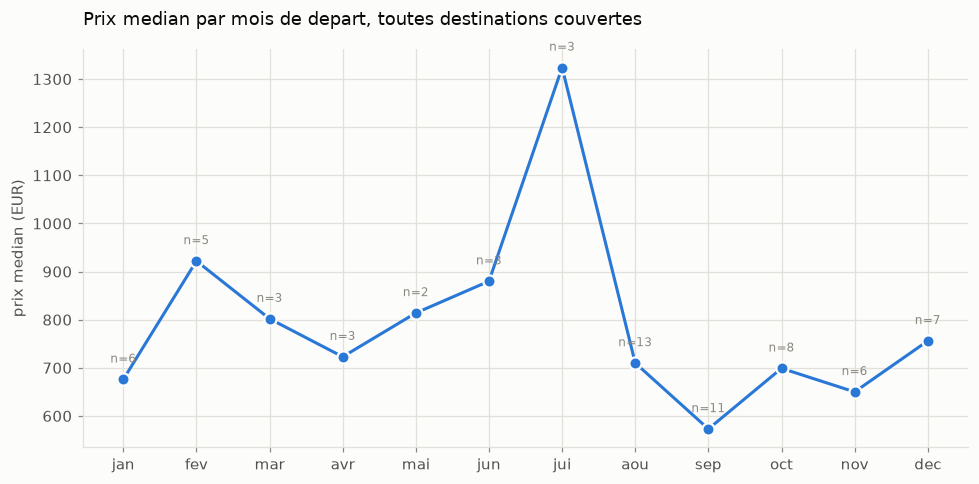

Le nombre d'observations est annote sur chaque point : sur un mois servi par
deux destinations seulement, une mediane n'a pas le meme statut que sur douze.


In [7]:
prix_mois = (
    snapshot.drop_nulls("price_eur")
    .with_columns(pl.col("month").dt.month().alias("mois"))
    .group_by("mois")
    .agg(
        pl.col("price_eur").median().alias("prix_median"),
        pl.len().alias("observations"),
    )
    .sort("mois")
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(prix_mois["mois"], prix_mois["prix_median"], color=CLAIR["serie"], marker="o",
        markeredgecolor=CLAIR["surface"], markeredgewidth=1.5)
for ligne in prix_mois.iter_rows(named=True):
    ax.annotate(f"n={ligne['observations']}", (ligne["mois"], ligne["prix_median"]),
                textcoords="offset points", xytext=(0, 11), ha="center",
                fontsize=8, color=CLAIR["encre_muette"])
ax.set_xticks(range(1, 13), MOIS)
ax.set_ylabel(f"prix median ({CONFIG.currency})")
ax.set_title("Prix median par mois de depart, toutes destinations couvertes",
             loc="left", pad=16, fontsize=12)
plt.tight_layout()
plt.show()

print("Le nombre d'observations est annote sur chaque point : sur un mois servi par")
print("deux destinations seulement, une mediane n'a pas le meme statut que sur douze.")

## 5. La question qui intéresse le produit : qualité contre prix

Si les bons mois étaient systématiquement les mois chers, le curseur n'aurait aucun
intérêt — il n'y aurait pas d'arbitrage, seulement une contrainte budgétaire.

In [8]:
tableau = construire_tableau()
couples = tableau.drop_nulls("price_eur").select("spot_id", "month", "p_surf", "price_eur")

xr = rangs(couples["p_surf"].to_numpy().astype(float))
yr = rangs(couples["price_eur"].to_numpy().astype(float))
rho = float(np.corrcoef(xr, yr)[0, 1])

print(f"{couples.height} couples spot-mois avec un prix ET une probabilite.")
print(f"Correlation de rangs qualite <-> prix : {rho:+.2f}")
print()
if abs(rho) < 0.2:
    print("Correlation faible : l'arbitrage existe vraiment, le curseur a du sens.")
elif rho > 0:
    print("Les bons mois tendent a etre les mois chers : l'arbitrage est reel mais contraint.")
else:
    print("Les bons mois tendent a etre les mois BON MARCHE : le curseur compte moins.")

70 couples spot-mois avec un prix ET une probabilite.
Correlation de rangs qualite <-> prix : +0.12

Correlation faible : l'arbitrage existe vraiment, le curseur a du sens.


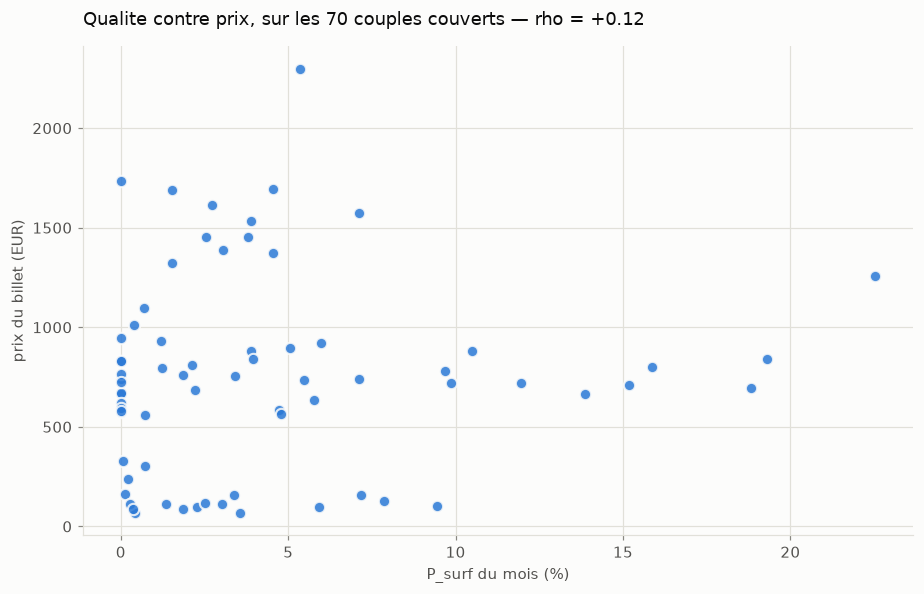

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(couples["p_surf"].to_numpy() * 100, couples["price_eur"].to_numpy(),
           s=55, color=CLAIR["serie"], edgecolor=CLAIR["surface"], linewidth=1.4, alpha=0.85)
ax.set_xlabel("P_surf du mois (%)")
ax.set_ylabel(f"prix du billet ({CONFIG.currency})")
ax.set_title(f"Qualite contre prix, sur les {couples.height} couples couverts — rho = {rho:+.2f}",
             loc="left", pad=14, fontsize=12)
plt.tight_layout()
plt.show()

## Ce qu'il faut retenir

- **15 destinations couvertes sur 20.** Le repli « référentiel restreint » s'applique,
  tel qu'il avait été écrit avant la mesure.
- **La corrélation couverture ↔ popularité est forte et positive.** Les cinq
  destinations sans prix sont exactement les cinq de popularité minimale.
- **Le produit à deux axes tient sur une définition généreuse de « couvert ».**
  À six mois servis exigés, il basculerait en mono-axe.
- **170 couples spot-mois sur 240 n'ont pas de prix.** L'axe prix mesure donc en
  bonne partie « a un prix », et pas seulement « est bon marché » — c'est la limite
  la plus sérieuse du classement actuel, et elle reste ouverte.

Ce dernier point n'est pas un détail de présentation : il touche au score lui-même.
Un spot non couvert reçoit un rang de prix nul, ce qui le **pénalise** au lieu de le
marquer neutre. En janvier, La Gravière est surfable 28,3 % des heures diurnes —
quarante fois Ponta Preta — et sort pourtant derrière elle à `alpha = 0,5`, faute de
prix.